### Import packages and load data

In [1]:
# Import Necessary Libraries

# Core data handling and numerical operations
import pandas as pd
import numpy as np
import time
import os

# Plotting libraries for visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Suppress warnings for a cleaner notebook
import warnings
warnings.filterwarnings('ignore')

# Import custom-built hurdle analysis pipeline
import hurdle_analysis_pipeline as hap

from scipy.signal import savgol_filter, find_peaks

# Load the Ground Truth Data
BASE_DIR = os.path.dirname(os.path.abspath(__file__))
ground_truth_df_path = os.path.join(BASE_DIR, "Biomechanic_Validation", "model_output_df.csv")
ground_truth_df = pd.read_csv(ground_truth_df_path)

print(ground_truth_df.head(14))

NameError: name '__file__' is not defined

### Run detection pipeline on multiple athletes in multiple races and save as df

#### Filter and pivot ground truth data

In [ ]:
# --- 3. Prepare the Ground Truth Data for Comparison ---

# Define the list of races we want to analyze
races_to_process = [
    ('World Championships', 2017),
    ('World Championships', 2013),
    ('Olympic Games', 2016),
    ('Olympic Games', 2020),
    ('Olympic Games', 2012)
]

# Create a list of boolean filters for each race
meeting_filters = [
    (ground_truth_df['Meeting'] == race[0]) & (ground_truth_df['Year'] == race[1])
    for race in races_to_process
]

# Combine the filters with an OR condition to select all relevant races
combined_filter = pd.concat(meeting_filters, axis=1).any(axis=1)
race_df = ground_truth_df[combined_filter].copy()

print(f"Found {race_df['Athlete'].nunique()} unique athletes across {len(races_to_process)} specified races.")

# --- Reshape the data from long to wide format ---
# We now include 'Meeting' and 'Year' in the index to keep each performance unique
ground_truth_pivot = race_df.pivot_table(
    index=['Meeting', 'Year', 'Athlete', 'Lane'], 
    columns='Metric', 
    values='Value'
).reset_index()

# --- Filter for athletes with complete data ---
required_columns = ['H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'Official Time']
complete_athletes_gt = ground_truth_pivot.dropna(subset=required_columns).copy()

# --- Calculate Interval Times from Cumulative Times ---
for i in range(1, 10):
    hurdle_current, hurdle_next = f'H{i}', f'H{i+1}'
    interval_col_name = f'H{i} to H{i+1}'
    complete_athletes_gt[interval_col_name] = (complete_athletes_gt[hurdle_next] - complete_athletes_gt[hurdle_current]).round(2)

complete_athletes_gt['Start to H1'] = complete_athletes_gt['H1']
complete_athletes_gt['H10 to Finish'] = (complete_athletes_gt['Official Time'] - complete_athletes_gt['H10']).round(2)

print(f"\nFound {len(complete_athletes_gt)} total athletes with complete data across all races.")
print("\nPrepared Ground Truth data (showing calculated intervals):")
display(complete_athletes_gt[['Meeting', 'Year', 'Athlete', 'Start to H1', 'H1 to H2']].head())

Found 28 unique athletes across 5 specified races.

Found 26 total athletes with complete data across all races.

Prepared Ground Truth data (showing calculated intervals):


Metric,Meeting,Year,Athlete,Start to H1,H1 to H2
0,Olympic Games,2012,"Clarke, Lawrence (GBR) (1990)",2.50,1.02
1,Olympic Games,2012,"Merritt, Aries (USA) (1985)",2.44,0.99
2,Olympic Games,2012,"Ortega, Orlando (CUB) (1991)",2.50,1.01
3,Olympic Games,2012,"Parchment, Hansle (JAM) (1990)",2.49,1.01
4,Olympic Games,2012,"Richardson, Jason (USA) (1986)",2.48,1.01


In [ ]:
# --- Helper function for formatting time ---
def format_time(seconds):
    """Converts seconds into a 'X minutes and Y.YY seconds' string."""
    minutes = int(seconds // 60)
    remaining_seconds = seconds % 60
    return f"{minutes} minutes and {remaining_seconds:.2f} seconds"

# --- 4. Run Analysis and Compare with Ground Truth ---

race_video_map = {
    ('World Championships', 2017): "/Users/Lucas/Documents/Hurdle_App/Races/iaaf 2017 f.mp4",
    ('World Championships', 2013): "/Users/Lucas/Documents/Hurdle_App/Races/iaaf 2013 f.mp4",
    ('Olympic Games', 2016): "/Users/Lucas/Documents/Hurdle_App/Races/O2016 F.mp4",
    ('Olympic Games', 2020): "/Users/Lucas/Documents/Hurdle_App/Races/O2020 F.mp4",
    ('Olympic Games', 2012): "/Users/Lucas/Documents/Hurdle_App/Races/O2012 F.mp4"
}

all_results = []
processing_times = []

# Loop through each race defined in our map
for race_key, video_path in race_video_map.items():
    meeting, year = race_key
    
    # Get the list of athletes for the current race
    athletes_in_race = complete_athletes_gt[
        (complete_athletes_gt['Meeting'] == meeting) & (complete_athletes_gt['Year'] == year)
    ]
    
    if athletes_in_race.empty:
        print(f"\nNo athletes with complete ground truth data found for {meeting} {year}. Skipping race.")
        continue
        
    print(f"\n{'='*60}")
    print(f"PROCESSING RACE: {meeting} {year}")
    print(f"Video File: {video_path}")
    print(f"{'='*60}")

    # Loop through each athlete in the current race
    for _, athlete_info in athletes_in_race.iterrows():
        
        start_time_athlete = time.time()
        
        athlete_name = athlete_info['Athlete']
        athlete_lane = athlete_info['Lane']
        
        print(f"\n--- Analyzing Athlete: {athlete_name} (Lane: {athlete_lane}) ---")
        
        # Load a fresh model instance for each athlete
        detection_model = hap.load_models()
        if not detection_model: 
            # Stop timer and record duration even on failure
            end_time_athlete = time.time()
            processing_times.append(end_time_athlete - start_time_athlete)
            print(f"--- Analysis for {athlete_name} FAILED (model load) in {format_time(end_time_athlete - start_time_athlete)} ---")
            continue
            
        class_ids = hap.get_class_ids(detection_model)
        if not class_ids: 
            # Stop timer and record duration even on failure
            end_time_athlete = time.time()
            processing_times.append(end_time_athlete - start_time_athlete)
            print(f"--- Analysis for {athlete_name} FAILED (class IDs) in {format_time(end_time_athlete - start_time_athlete)} ---")
            continue

        # Run the full pipeline
        target_id, first_frame_athletes = hap.select_athlete_from_video(video_path, detection_model, class_ids)
        if target_id is None:
            print(f"Skipping athlete {athlete_name} (no selection).")
            # Stop timer and record duration even on skip
            end_time_athlete = time.time()
            processing_times.append(end_time_athlete - start_time_athlete)
            print(f"--- Analysis for {athlete_name} SKIPPED in {format_time(end_time_athlete - start_time_athlete)} ---")
            continue
            
        trajectory_df, start_frame = hap.track_athlete(video_path, detection_model, class_ids, target_id, first_frame_athletes)
        if trajectory_df.empty:
            print(f"Tracking failed for {athlete_name}. Skipping.")
            # Stop timer and record duration even on failure
            end_time_athlete = time.time()
            processing_times.append(end_time_athlete - start_time_athlete)
            print(f"--- Analysis for {athlete_name} FAILED (tracking) in {format_time(end_time_athlete - start_time_athlete)} ---")
            continue

        hurdle_peaks = hap.find_hurdle_peaks(trajectory_df)
        finish_frame = hap.find_finish_line_cross(video_path, detection_model, class_ids, trajectory_df)
        
        if hurdle_peaks and len(hurdle_peaks) == 10:
            segment_df, flight_df, total_time, _ = hap.calculate_metrics_and_report(
                video_path, detection_model, class_ids, start_frame, finish_frame, hurdle_peaks, trajectory_df
            )
            model_intervals = segment_df.set_index('Segment')['Time (s)'].astype(float).to_dict()
            model_intervals['Athlete'] = athlete_name
            # Add race info to uniquely identify this result
            model_intervals['Meeting'] = meeting
            model_intervals['Year'] = year
            all_results.append(model_intervals)
        else:
            print(f"Could not find 10 hurdles for {athlete_name}. Skipping.")

        
        end_time_athlete = time.time()
        duration_seconds = end_time_athlete - start_time_athlete
        processing_times.append(duration_seconds)
        print(f"--- Analysis for {athlete_name} COMPLETED in {format_time(duration_seconds)} ---")


# --- 5. Create Final Comparison DataFrame ---
if all_results:
    model_results_df = pd.DataFrame(all_results)
    
    # Define columns for merging and comparison
    merge_cols = ['Meeting', 'Year', 'Athlete']
    comparison_cols = ['Start to H1'] + [f'H{i} to H{i+1}' for i in range(1, 10)] + ['H10 to Finish']
    
    # Ensure data types are correct for merging and calculation
    for df in [complete_athletes_gt, model_results_df]:
        for col in comparison_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
    
    comparison_df = pd.merge(
        complete_athletes_gt[merge_cols + comparison_cols],
        model_results_df[merge_cols + comparison_cols],
        on=merge_cols,
        suffixes=('_GT', '_Model')
    )
    
    for col in comparison_cols:
        comparison_df[f"{col}_Error"] = (comparison_df[f'{col}_Model'] - comparison_df[f'{col}_GT']).abs()

    print("\n\n--- FINAL COMPARISON REPORT (ALL RACES) ---")
    display(comparison_df)
else:
    print("\n\n--- No results were generated from the pipeline. ---")

print("\n\n--- 6. Processing Time Statistics ---")
if processing_times:
    # Use numpy for easy mean and std calculation
    avg_time_sec = np.mean(processing_times)
    std_time_sec = np.std(processing_times)
    
    print(f"Total athletes analyzed: {len(processing_times)}")
    print(f"Average time per athlete: {format_time(avg_time_sec)}")
    print(f"Standard deviation of time: {format_time(std_time_sec)}")
else:
    print("No athletes were processed.")


PROCESSING RACE: World Championships 2017
Video File: /Users/Lucas/Documents/Hurdle_App/Races/iaaf 2017 f.mp4

--- Analyzing Athlete: Baji, Balazs (HUN) (1989) (Lane: 7) ---

--- Loading detection model... ---
✅ Target athlete ID: 4 selected.

--- Starting Pass 1: Tracking athlete's bounding box... ---
🚀 Motion detected! Race starts at frame: 79
✅ Pass 1 Complete. Logged 362 data points.

--- Analyzing Trajectory: Using Enhanced Two-Factor Peak Detection... ---
Calculated Y-Prominence Threshold: 3.5786
Calculated AR-Prominence Threshold: 0.0432
Found 13 raw vertical peaks and 12 raw aspect ratio peaks.
✅ Analysis Complete. Identified 10 potential hurdle events.

--- Starting Pass 2: Finding Finish Line (with 25.0% buffer)... ---
🏁 Finish Line crossed at frame: 436 (Buffer Trigger: 646.30px)
✅ Pass 2 Complete.

--- Starting Pass 3: Calculating Final Metrics... ---

--- Race Segment Analysis ---
      Segment  Time (s)  Velocity (m/s)
  Start to H1      3.36            4.08
     H1 to H

,Meeting,Year,Athlete,Start to H1_GT,H1 to H2_GT,H2 to H3_GT,H3 to H4_GT,H4 to H5_GT,H5 to H6_GT,H6 to H7_GT,...,H1 to H2_Error,H2 to H3_Error,H3 to H4_Error,H4 to H5_Error,H5 to H6_Error,H6 to H7_Error,H7 to H8_Error,H8 to H9_Error,H9 to H10_Error,H10 to Finish_Error
0,Olympic Games,2012,"Merritt, Aries (USA) (1985)",2.44,0.99,0.97,0.98,0.98,0.98,0.98,...,0.05,0.01,0.02,0.02,0.02,0.02,0.01,0.03,0.01,0.01
1,Olympic Games,2012,"Ortega, Orlando (CUB) (1991)",2.50,1.01,1.00,1.00,1.00,1.00,1.02,...,0.11,0.00,0.00,0.00,0.00,0.02,0.18,0.13,0.11,0.14
2,Olympic Games,2012,"Parchment, Hansle (JAM) (1990)",2.49,1.01,1.00,1.00,0.99,0.99,1.00,...,0.11,0.00,0.04,0.03,0.01,0.00,0.01,0.05,0.05,0.01
3,Olympic Games,2012,"Richardson, Jason (USA) (1986)",2.48,1.01,0.99,0.98,0.98,0.98,0.99,...,0.03,0.01,0.02,0.02,0.02,0.05,0.04,0.98,0.12,0.93
4,Olympic Games,2016,"Bascou, Dimitri (FRA) (1987)",2.47,1.02,1.01,1.00,0.99,1.00,1.01,...,0.14,0.01,0.00,0.07,0.08,0.01,0.02,0.09,0.91,1.04
5,Olympic Games,2016,"Martinot-Lagarde, Pascal (FRA) (1991)",2.49,1.03,1.00,1.00,0.99,0.99,1.00,...,0.69,0.20,0.04,0.05,0.07,0.04,0.10,0.97,0.11,0.05
6,Olympic Games,2016,"McLeod, Omar (JAM) (1994)",2.44,1.02,0.99,0.98,0.99,0.98,0.99,...,0.14,0.01,0.02,0.03,0.02,0.01,0.04,0.01,0.09,0.02
7,Olympic Games,2016,"Ortega, Orlando (ESP) (1991)",2.47,1.01,1.01,1.00,1.00,0.99,1.00,...,0.11,0.01,0.00,0.04,0.01,0.00,0.02,0.01,0.09,0.09
8,Olympic Games,2020,"Allen, Devon (USA) (1994)",2.43,1.02,1.00,0.99,0.99,1.00,1.01,...,0.10,0.08,0.01,0.01,0.00,0.07,0.07,0.08,0.05,10.18
9,Olympic Games,2020,"Belocian, Wilhem (FRA) (1995)",2.44,1.03,1.00,1.00,1.01,1.02,1.03,...,1.01,0.04,0.04,0.03,0.02,0.03,0.00,0.00,0.84,1.83




--- 6. Processing Time Statistics ---
Total athletes analyzed: 26
Average time per athlete: 1 minutes and 12.42 seconds
Standard deviation of time: 0 minutes and 12.66 seconds


--- 1. Mean Absolute Error (MAE) ---
The MAE tells us, on average, how many seconds our model's prediction is off from the ground truth.

Mean Error by Segment (seconds):
H10 to Finish_Error    1.897273
Start to H1_Error      0.807273
H1 to H2_Error         0.268182
H9 to H10_Error        0.258636
H8 to H9_Error         0.203182
H5 to H6_Error         0.086364
H7 to H8_Error         0.077273
H6 to H7_Error         0.061364
H2 to H3_Error         0.042273
H4 to H5_Error         0.033182
H3 to H4_Error         0.029545
dtype: float64

-------------------------------------------
Overall Mean Absolute Error: 0.342 seconds
-------------------------------------------


--- 2. Paired t-test for Significance ---
The t-test checks if the difference between our model and the ground truth is statistically significant.
A low p-value (typically < 0.05) suggests the difference is real and not just random chance.


,Segment,t-statistic,p-value,Significant (p < 0.05)
0,Start to H1,-0.051197,0.959652,No
1,H1 to H2,-3.731985,0.001231,Yes
2,H2 to H3,-1.275862,0.215937,No
3,H3 to H4,1.479441,0.153868,No
4,H4 to H5,1.548536,0.136433,No
5,H5 to H6,-1.135164,0.269098,No
6,H6 to H7,-0.757613,0.457100,No
7,H7 to H8,-2.104403,0.047564,Yes
8,H8 to H9,-1.437561,0.165294,No
9,H9 to H10,-2.343085,0.029049,Yes



--- Calculating Velocities ---
Velocity calculations complete.


--- 3. Visual Comparison ---


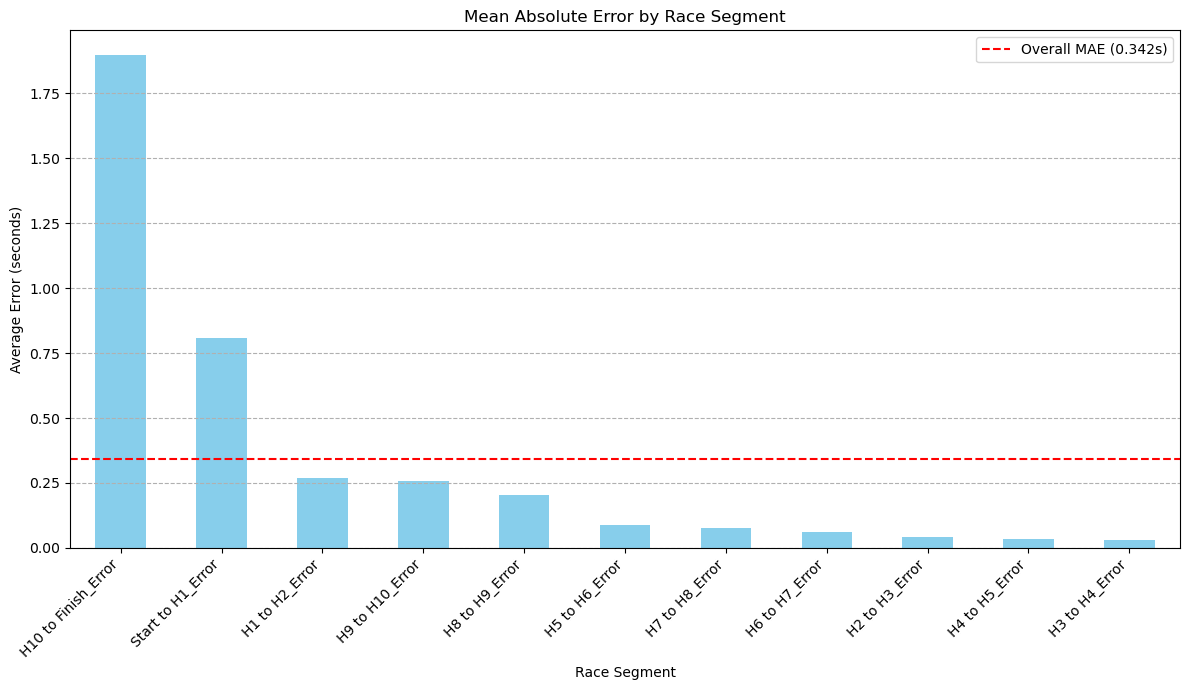

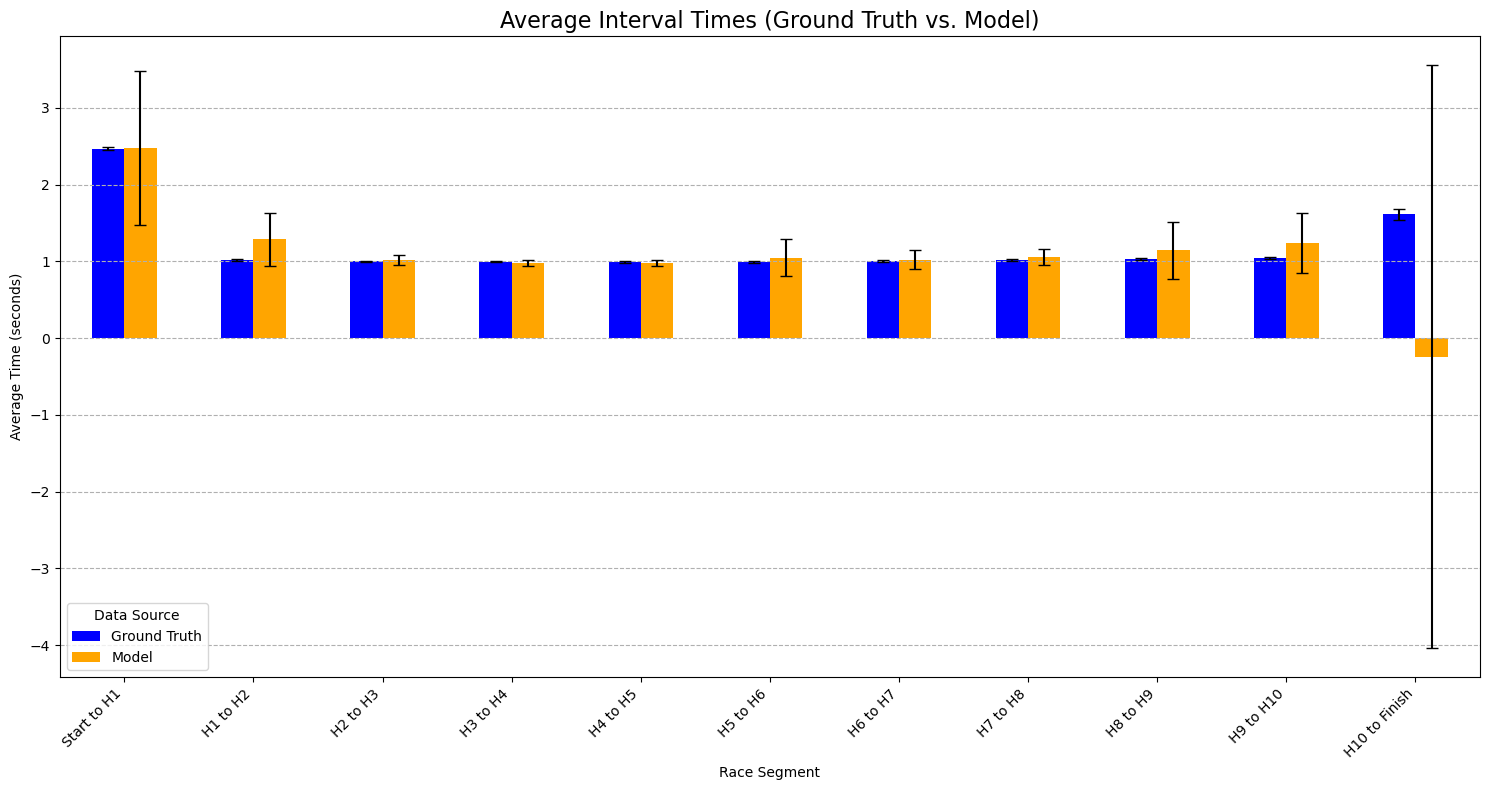

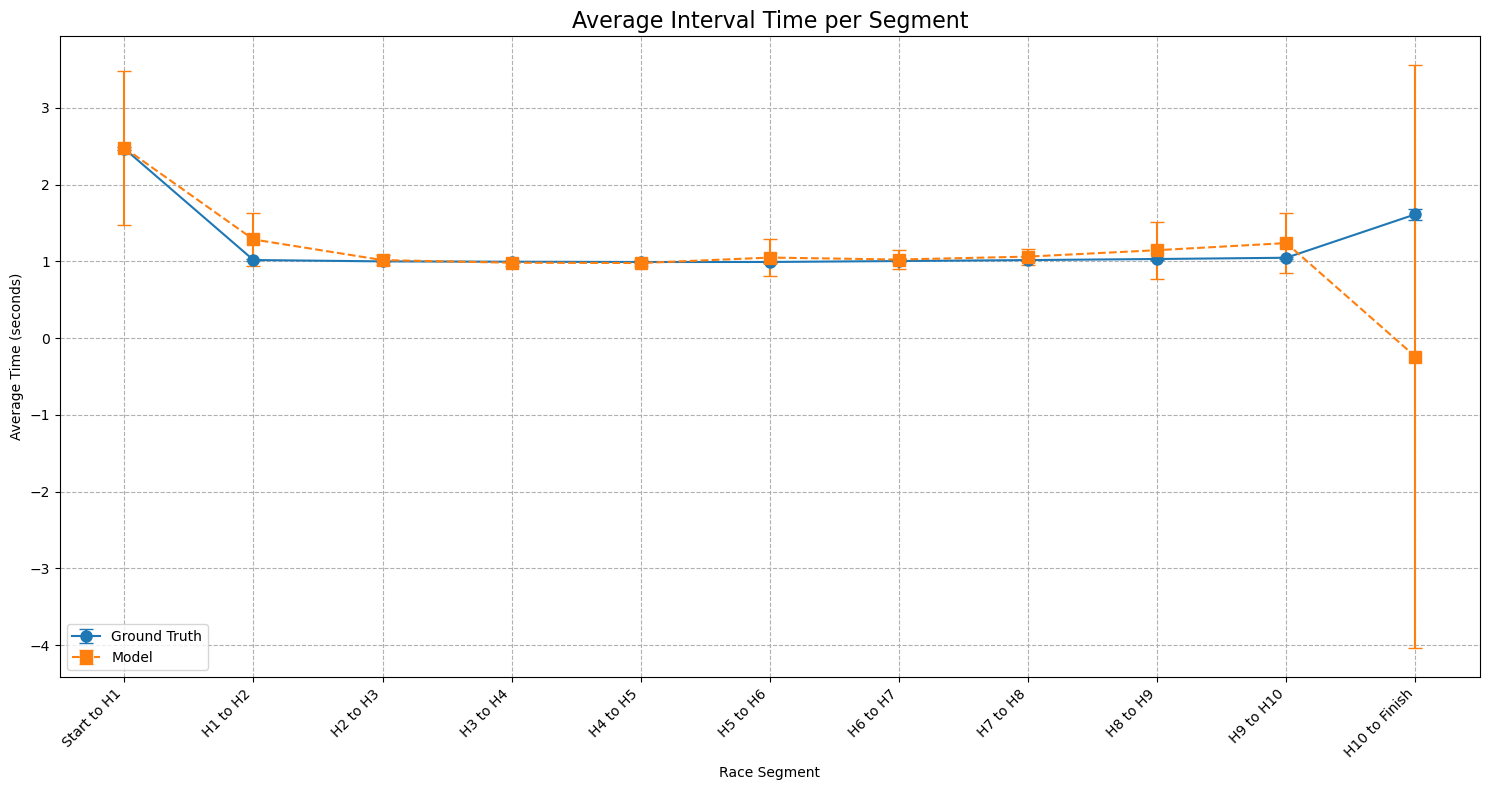

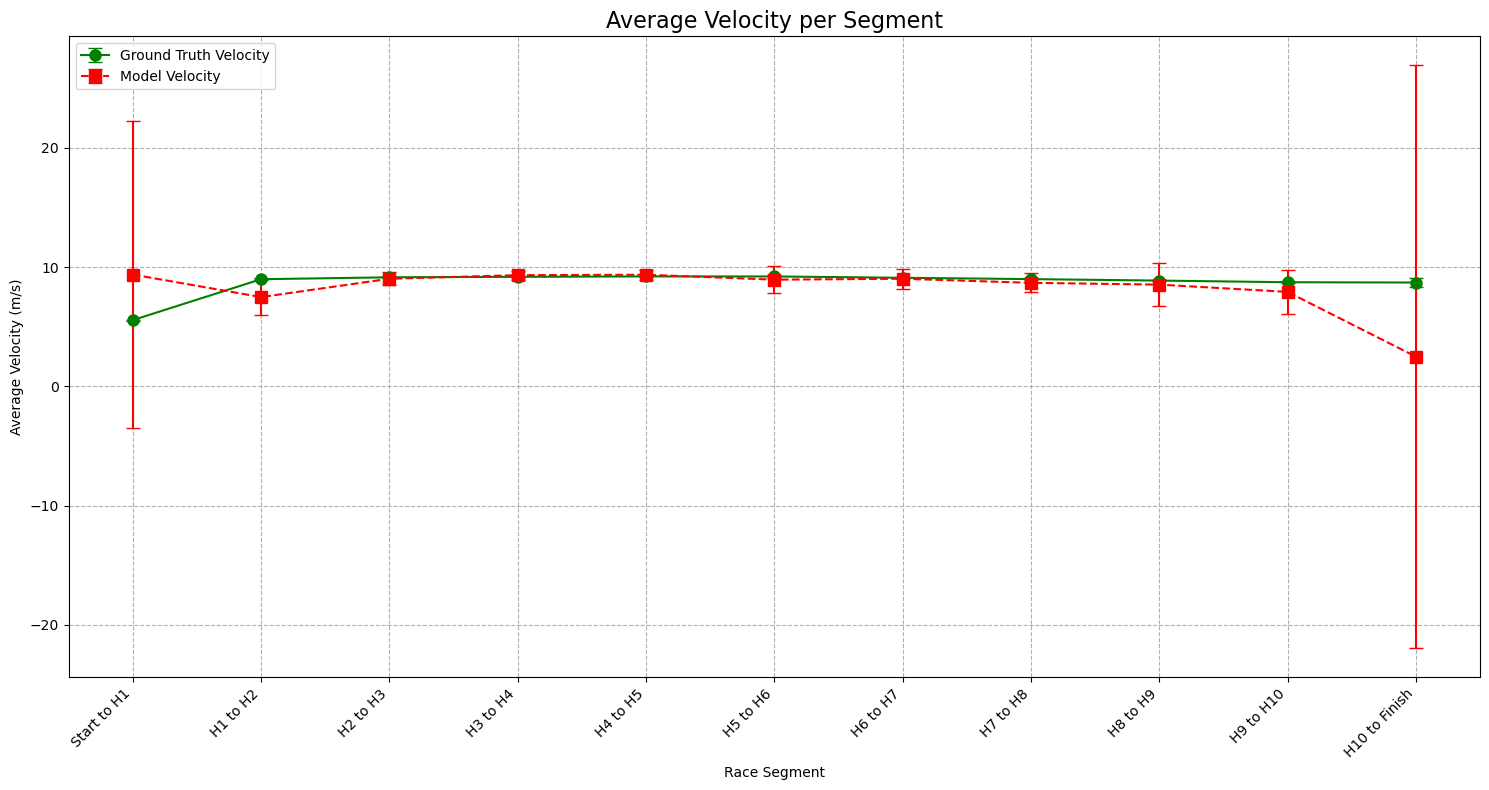

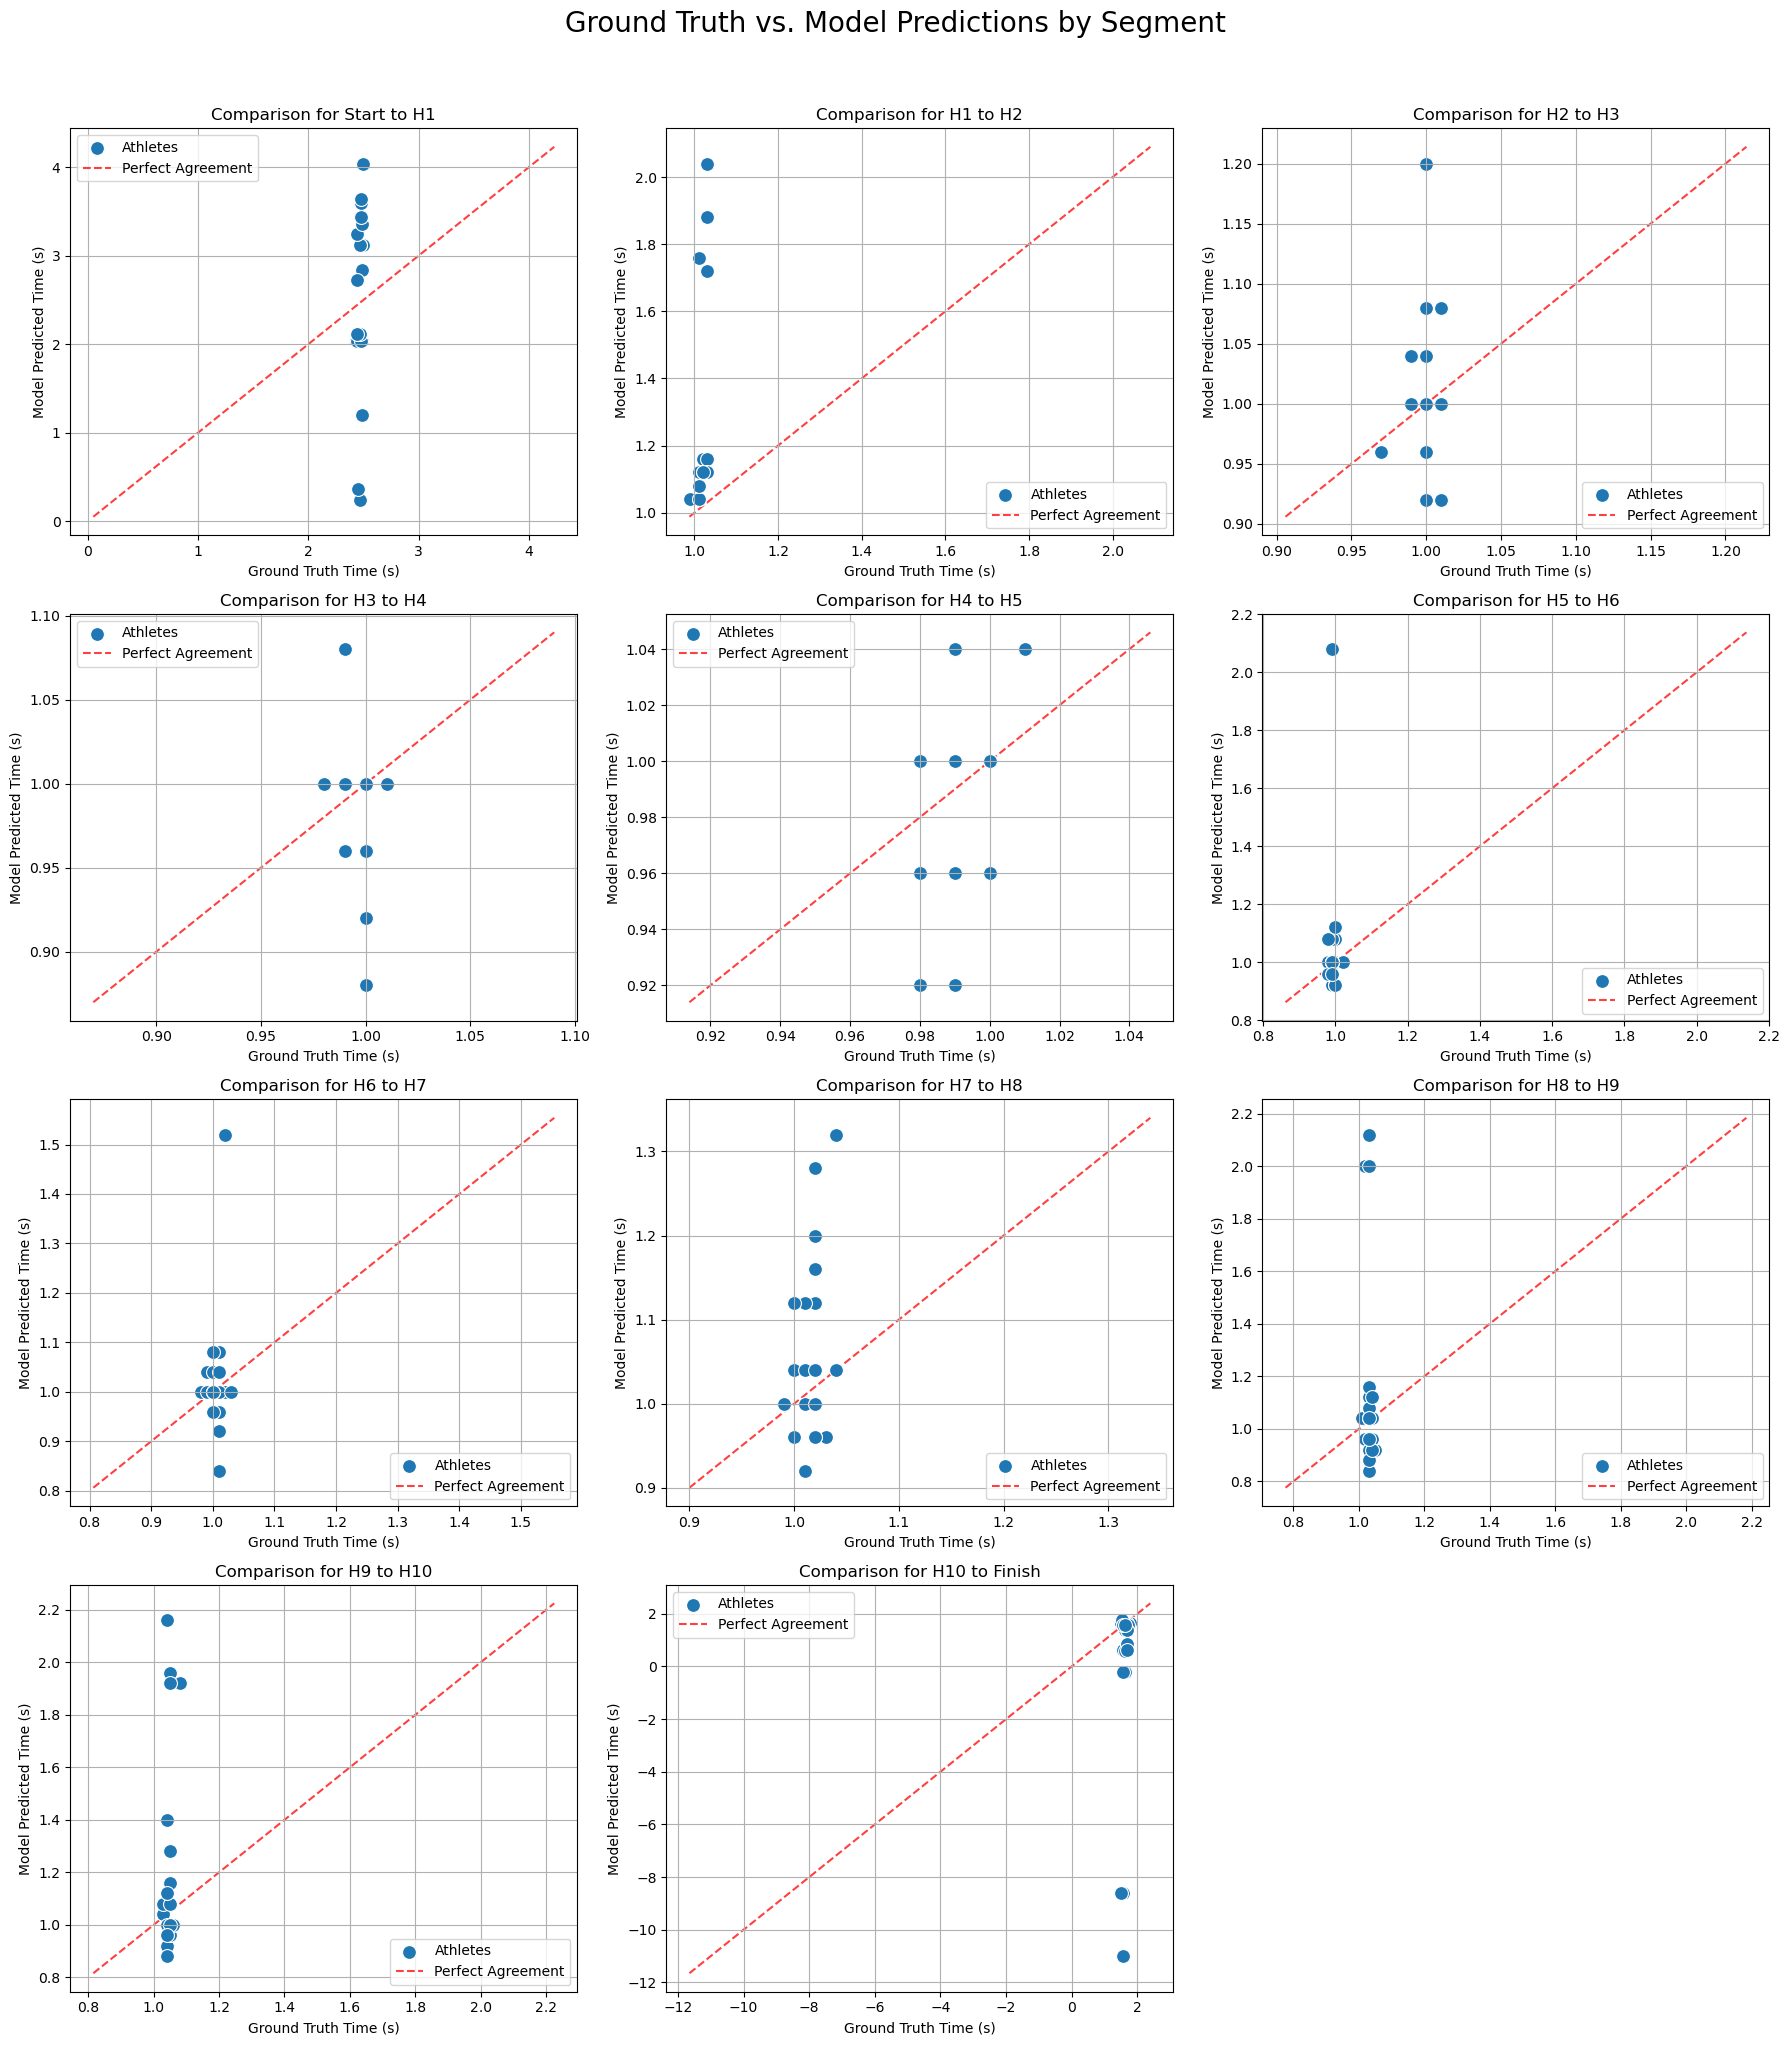

In [ ]:
# --- 6. Statistical Validation and Visualization ---
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'comparison_df' in locals() and not comparison_df.empty:
    
    # Define the segments and their standard distances (in meters)
    comparison_cols = ['Start to H1'] + [f'H{i} to H{i+1}' for i in range(1, 10)] + ['H10 to Finish']
    distances = [13.72] + [9.14] * 9 + [14.02]
    segment_distances = dict(zip(comparison_cols, distances))
    
    # --- a) Mean Absolute Error (MAE) ---
    error_cols = [col for col in comparison_df.columns if '_Error' in col]
    mae_by_segment = comparison_df[error_cols].mean().sort_values(ascending=False)
    overall_mae = comparison_df[error_cols].values.mean()
    
    print("--- 1. Mean Absolute Error (MAE) ---")
    print("\nMean Error by Segment (seconds):")
    print(mae_by_segment)
    print("\n-------------------------------------------")
    print(f"Overall Mean Absolute Error: {overall_mae:.3f} seconds")
    print("-------------------------------------------\n")

    # --- b) Significance Testing (Paired t-test) ---
    print("\n--- 2. Paired t-test for Significance ---")
    
    ttest_results = []

    for col in comparison_cols:
        gt_values = comparison_df[f'{col}_GT']
        model_values = comparison_df[f'{col}_Model']
        
        if len(gt_values) > 1:
            t_stat, p_value = stats.ttest_rel(gt_values, model_values)
            ttest_results.append({
                'Segment': col,
                't-statistic': t_stat,
                'p-value': p_value,
                'Significant (p < 0.05)': 'Yes' if p_value < 0.05 else 'No'
            })
    
    if ttest_results:
        ttest_df = pd.DataFrame(ttest_results)
        display(ttest_df)
    else:
        print("Not enough data to perform a paired t-test (need at least 2 athletes).")

    # --- c) Calculate Velocities ---
    print("\n--- Calculating Velocities ---")
    gt_vel_cols = []
    model_vel_cols = []
    
    for col, dist in segment_distances.items():
        gt_vel_col = f'{col}_GT_Velocity'
        model_vel_col = f'{col}_Model_Velocity'
        
        comparison_df[gt_vel_col] = dist / comparison_df[f'{col}_GT']
        comparison_df[model_vel_col] = dist / comparison_df[f'{col}_Model']
        
        gt_vel_cols.append(gt_vel_col)
        model_vel_cols.append(model_vel_col)
        
    print("Velocity calculations complete.")


    # --- d) Visualizations ---
    print("\n\n--- 3. Visual Comparison ---")
    
    # 1. Bar Plot of MAE
    plt.figure(figsize=(12, 7))
    mae_by_segment.plot(kind='bar', color='skyblue')
    plt.axhline(y=overall_mae, color='r', linestyle='--', label=f'Overall MAE ({overall_mae:.3f}s)')
    plt.title('Mean Absolute Error by Race Segment')
    plt.ylabel('Average Error (seconds)')
    plt.xlabel('Race Segment')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()

    # --- 2. Grouped Bar Plot of Interval Times ---
    
    # Calculate means and stds for times
    gt_cols = [f'{col}_GT' for col in comparison_cols]
    model_cols = [f'{col}_Model' for col in comparison_cols]
    
    mean_times_df = pd.DataFrame({
        'Ground Truth': comparison_df[gt_cols].mean().values,
        'Model': comparison_df[model_cols].mean().values
    }, index=comparison_cols)
    
    std_times_df = pd.DataFrame({
        'Ground Truth': comparison_df[gt_cols].std().values,
        'Model': comparison_df[model_cols].std().values
    }, index=comparison_cols)

    # Plotting the grouped bar chart
    ax = mean_times_df.plot(
        kind='bar', 
        yerr=std_times_df, 
        figsize=(15, 8), 
        capsize=4, 
        color={'Ground Truth': 'blue', 'Model': 'orange'}
    )
    ax.set_title('Average Interval Times (Ground Truth vs. Model)', fontsize=16)
    ax.set_ylabel('Average Time (seconds)')
    ax.set_xlabel('Race Segment')
    ax.legend(title='Data Source')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()

    # --- 3. Line Plot of Average Interval Times ---
    
    plt.figure(figsize=(15, 8))
    
    # Get the stats we calculated
    x_segments = mean_times_df.index
    mean_gt = mean_times_df['Ground Truth']
    std_gt = std_times_df['Ground Truth']
    mean_model = mean_times_df['Model']
    std_model = std_times_df['Model']
    
    # Plot Ground Truth
    plt.errorbar(x_segments, mean_gt, yerr=std_gt, label='Ground Truth', 
                 marker='o', capsize=5, linestyle='-', markersize=8)
    
    # Plot Model
    plt.errorbar(x_segments, mean_model, yerr=std_model, label='Model', 
                 marker='s', capsize=5, linestyle='--', markersize=8)
    
    plt.title('Average Interval Time per Segment', fontsize=16)
    plt.ylabel('Average Time (seconds)')
    plt.xlabel('Race Segment')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.tight_layout()
    plt.show()

    # --- ADDED: 4. Line Plot of Average Velocity ---
    
    # Calculate means and stds for velocities
    mean_vels_df = pd.DataFrame({
        'Ground Truth': comparison_df[gt_vel_cols].mean().values,
        'Model': comparison_df[model_vel_cols].mean().values
    }, index=comparison_cols)
    
    std_vels_df = pd.DataFrame({
        'Ground Truth': comparison_df[gt_vel_cols].std().values,
        'Model': comparison_df[model_vel_cols].std().values
    }, index=comparison_cols)
    
    plt.figure(figsize=(15, 8))
    
    # Get the stats
    x_segments = mean_vels_df.index
    mean_gt_vel = mean_vels_df['Ground Truth']
    std_gt_vel = std_vels_df['Ground Truth']
    mean_model_vel = mean_vels_df['Model']
    std_model_vel = std_vels_df['Model']
    
    # Plot Ground Truth Velocity
    plt.errorbar(x_segments, mean_gt_vel, yerr=std_gt_vel, label='Ground Truth Velocity', 
                 marker='o', capsize=5, linestyle='-', markersize=8, color='green')
    
    # Plot Model Velocity
    plt.errorbar(x_segments, mean_model_vel, yerr=std_model_vel, label='Model Velocity', 
                 marker='s', capsize=5, linestyle='--', markersize=8, color='red')
    
    plt.title('Average Velocity per Segment', fontsize=16)
    plt.ylabel('Average Velocity (m/s)')
    plt.xlabel('Race Segment')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.tight_layout()
    plt.show()


    # 5. Scatter Plots for Ground Truth vs. Model (Original plot, renumbered)
    num_segments = len(comparison_cols)
    fig, axes = plt.subplots((num_segments + 2) // 3, 3, figsize=(18, 5 * ((num_segments + 2) // 3)))
    axes = axes.flatten()

    for i, col in enumerate(comparison_cols):
        ax = axes[i]
        sns.scatterplot(data=comparison_df, x=f'{col}_GT', y=f'{col}_Model', ax=ax, s=100, label='Athletes')
        
        lims = [
            np.min([ax.get_xlim(), ax.get_ylim()]),
            np.max([ax.get_xlim(), ax.get_ylim()]),
        ]
        ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Perfect Agreement')
        
        ax.set_title(f'Comparison for {col}')
        ax.set_xlabel('Ground Truth Time (s)')
        ax.set_ylabel('Model Predicted Time (s)')
        ax.legend()
        ax.grid(True)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    fig.suptitle('Ground Truth vs. Model Predictions by Segment', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

else:
    print("No comparison data available to generate statistics.")

In [ ]:
print(ttest_df)

          Segment  t-statistic   p-value Significant (p < 0.05)
0     Start to H1     5.879156  0.000012                    Yes
1        H1 to H2    -3.725425  0.001434                    Yes
2        H2 to H3    -0.875551  0.392209                     No
3        H3 to H4    -0.974185  0.342205                     No
4        H4 to H5     2.437995  0.024763                    Yes
5        H5 to H6    -1.014144  0.323255                     No
6        H6 to H7    -0.747919  0.463666                     No
7        H7 to H8    -0.988627  0.335270                     No
8        H8 to H9    -2.612965  0.017105                    Yes
9       H9 to H10    -2.149685  0.044673                    Yes
10  H10 to Finish     2.344902  0.030046                    Yes


## Signal Peak Graph


--- Loading detection model... ---
Please select the athlete...
✅ Target athlete ID: 1 selected.

--- Starting Pass 1: Tracking athlete's bounding box... ---
🚀 Motion detected! Race starts at frame: 110
✅ Pass 1 Complete. Logged 331 data points.
Tracking complete. 331 frames captured.
Detected 11 hurdle peaks at indices: [ 22  53  80 106 130 154 181 205 233 257 282]


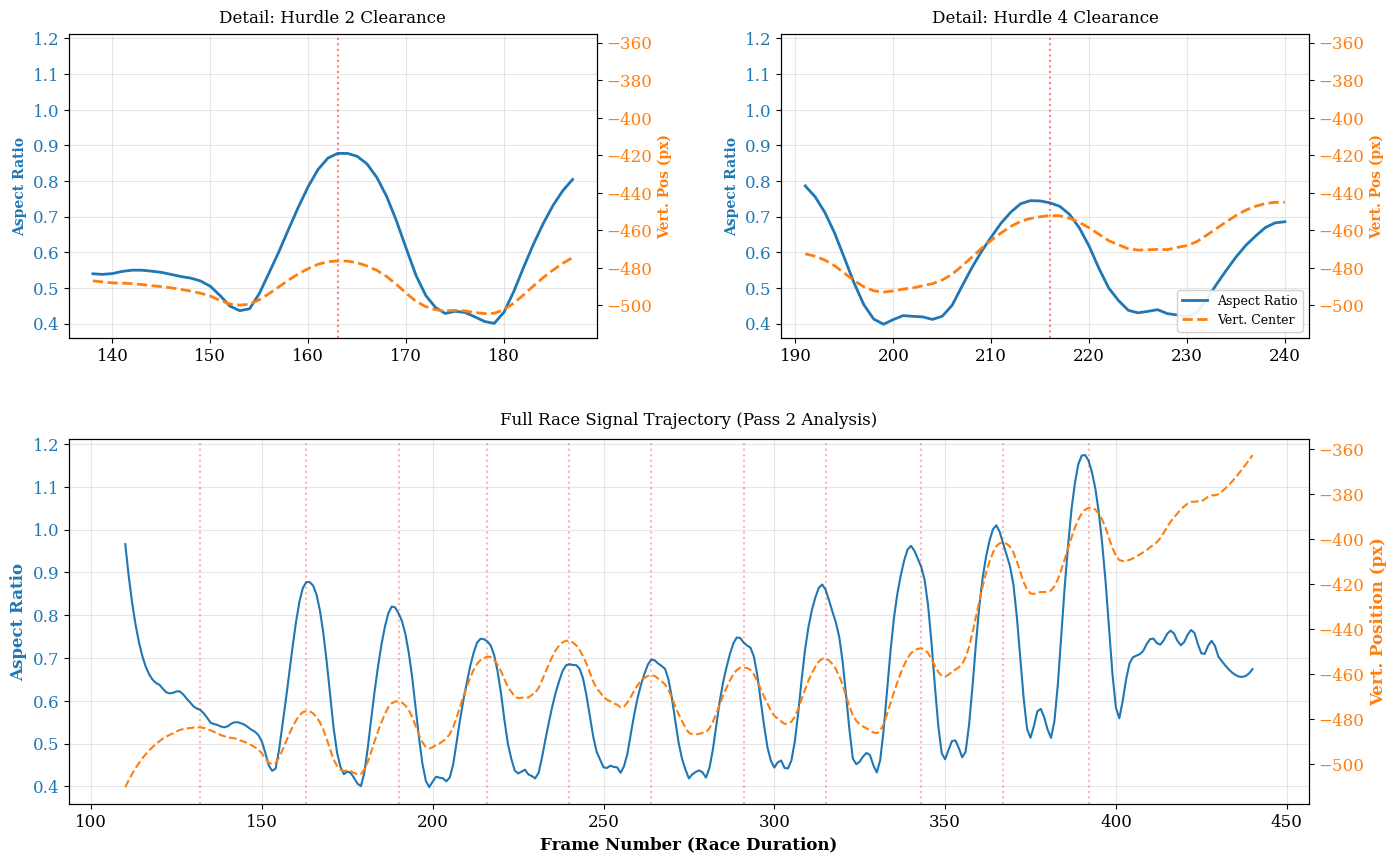

Figure saved to figure_3_hurdle_signal.png


In [ ]:
# --- Configuration ---
VIDEO_PATH = "/Users/Lucas/Documents/Hurdle_App/Races/iaaf 2017 f.mp4" 
MODEL_PATH = "/Users/Lucas/Documents/Hurdle_App/Races/yolo11s_tuned.pt" 
OUTPUT_FILENAME = "figure_3_hurdle_signal.png"

# Track Athlete and Get Data

detection_model = hap.load_models(MODEL_PATH)
class_ids = hap.get_class_ids(detection_model)

print("Please select the athlete...")
target_id, first_frame_athletes = hap.select_athlete_from_video(VIDEO_PATH, detection_model, class_ids)

if target_id is not None:
    trajectory_df, start_frame = hap.track_athlete(VIDEO_PATH, detection_model, class_ids, target_id, first_frame_athletes)
    print(f"Tracking complete. {len(trajectory_df)} frames captured.")
else:
    raise ValueError("No athlete selected.")


# Process Signals & Calculate Global Limits
# 1. Parse Coordinates
box_coords = trajectory_df['box'].str.extract(r'\[\s*(\d+\.?\d*)\s+(\d+\.?\d*)\s+(\d+\.?\d*)\s+(\d+\.?\d*)\s*\]').astype(float)
trajectory_df['y1'] = box_coords[1]
trajectory_df['y2'] = box_coords[3]
trajectory_df['x1'] = box_coords[0]
trajectory_df['x2'] = box_coords[2]

# 2. Calculate Signals
# Inverted Y-Center 
trajectory_df['y_center_inv'] = -((trajectory_df['y1'] + trajectory_df['y2']) / 2)
# Aspect Ratio (Width / Height)
trajectory_df['aspect_ratio'] = (trajectory_df['x2'] - trajectory_df['x1']) / (trajectory_df['y2'] - trajectory_df['y1'])

# 3. Apply Smoothing (Savgol)
trajectory_df['y_smooth'] = savgol_filter(trajectory_df['y_center_inv'], 21, 3)
trajectory_df['ar_smooth'] = savgol_filter(trajectory_df['aspect_ratio'], 21, 3)

# 4. Find Peaks
peaks, _ = find_peaks(trajectory_df['y_smooth'], prominence=10, distance=20)
print(f"Detected {len(peaks)} hurdle peaks at indices: {peaks}")
margin = 0.05

# Aspect Ratio Limits
ar_min = trajectory_df['ar_smooth'].min()
ar_max = trajectory_df['ar_smooth'].max()
ar_range = ar_max - ar_min
ar_lims = (ar_min - (ar_range * margin), ar_max + (ar_range * margin))

# Vertical Center Limits
y_min = trajectory_df['y_smooth'].min()
y_max = trajectory_df['y_smooth'].max()
y_range = y_max - y_min
y_lims = (y_min - (y_range * margin), y_max + (y_range * margin))

# 3. Generate the Multi-Panel Figure

def plot_signal_on_ax(ax, data, title, ar_limits, y_limits):
    """Helper to plot dual-axis signals with FORCED limits."""
    
    frames = data['frame']
    
    # Left Axis: Aspect Ratio
    color1 = '#1f77b4' # Blue
    ax.plot(frames, data['ar_smooth'], color=color1, linewidth=2, label='Aspect Ratio')
    ax.set_ylabel('Aspect Ratio', color=color1, fontweight='bold', fontsize=10)
    ax.tick_params(axis='y', labelcolor=color1)
    ax.set_ylim(ar_limits) # <--- Force Scale
    
    # Right Axis: Vertical Center
    ax2 = ax.twinx()
    color2 = '#ff7f0e' # Orange
    ax2.plot(frames, data['y_smooth'], color=color2, linewidth=2, linestyle='--', label='Vert. Center')
    ax2.set_ylabel('Vert. Pos (px)', color=color2, fontweight='bold', fontsize=10)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(y_limits) # <--- Force Scale
    
    ax.set_title(title, fontsize=12, pad=8)
    ax.grid(True, alpha=0.3)
    
    return ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0], \
           ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]

# --- Setup Figure ---
fig = plt.figure(figsize=(16, 10)) 
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.3, wspace=0.35) # Increased wspace

# Define Axes
ax_h2 = fig.add_subplot(gs[0, 0]) # Top Left
ax_h4 = fig.add_subplot(gs[0, 1]) # Top Right
ax_full = fig.add_subplot(gs[1, :]) # Bottom

# --- 1. Plot Hurdle 2 (Second Peak) ---
if len(peaks) > 1:
    h2_idx = peaks[1]
    h2_data = trajectory_df.iloc[max(0, h2_idx-25):min(len(trajectory_df), h2_idx+25)]
    plot_signal_on_ax(ax_h2, h2_data, "Detail: Hurdle 2 Clearance", ar_lims, y_lims)
    ax_h2.axvline(trajectory_df.iloc[h2_idx]['frame'], color='red', alpha=0.5, linestyle=':')
else:
    ax_h2.text(0.5, 0.5, "Hurdle 2 Not Detected", ha='center')

# --- 2. Plot Hurdle 4 (Fourth Peak) ---
if len(peaks) > 3:
    h4_idx = peaks[3] 
    h4_data = trajectory_df.iloc[max(0, h4_idx-25):min(len(trajectory_df), h4_idx+25)]
    handles, labels = plot_signal_on_ax(ax_h4, h4_data, "Detail: Hurdle 4 Clearance", ar_lims, y_lims)
    ax_h4.axvline(trajectory_df.iloc[h4_idx]['frame'], color='red', alpha=0.5, linestyle=':')
    
    # Legend
    ax_h4.legend(handles, labels, loc='lower right', fontsize=9, framealpha=0.9, facecolor='white')

elif len(peaks) > 2: 
    h3_idx = peaks[2]
    h3_data = trajectory_df.iloc[max(0, h3_idx-25):min(len(trajectory_df), h3_idx+25)]
    handles, labels = plot_signal_on_ax(ax_h4, h3_data, "Detail: Hurdle 3 Clearance", ar_lims, y_lims)
    ax_h4.legend(handles, labels, loc='lower right', fontsize=9)
else:
    ax_h4.text(0.5, 0.5, "Late Hurdle Not Detected", ha='center')

# --- 3. Plot Full Race ---
frames = trajectory_df['frame']
color1 = '#1f77b4'
color2 = '#ff7f0e'

ax_full.plot(frames, trajectory_df['ar_smooth'], color=color1, linewidth=1.5, label='Aspect Ratio')
ax_full.set_ylabel('Aspect Ratio', color=color1, fontweight='bold')
ax_full.tick_params(axis='y', labelcolor=color1)
ax_full.set_ylim(ar_lims) 

ax_full_2 = ax_full.twinx()
ax_full_2.plot(frames, trajectory_df['y_smooth'], color=color2, linewidth=1.5, linestyle='--', label='Vert. Center')
ax_full_2.set_ylabel('Vert. Position (px)', color=color2, fontweight='bold')
ax_full_2.tick_params(axis='y', labelcolor=color2)
ax_full_2.set_ylim(y_lims) 

ax_full.set_title("Full Race Signal Trajectory (Pass 2 Analysis)", fontsize=12, pad=10)
ax_full.set_xlabel('Frame Number (Race Duration)', fontsize=12, fontweight='bold')
ax_full.grid(True, alpha=0.3)

for p in peaks:
    ax_full.axvline(trajectory_df.iloc[p]['frame'], color='red', alpha=0.3, linestyle=':')

plt.savefig(OUTPUT_FILENAME, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved to {OUTPUT_FILENAME}")